# Connect-4 Minimax (Alpha–Beta) — From First Principles

_Generated: 2025-10-22T17:30:54.409279Z_

This notebook implements **Connect‑4** with a from-scratch **minimax** search and **alpha–beta pruning**. It includes a robust **heuristic evaluator**, **move ordering**, an optional **transposition table**, and depth/time limits. A simple matplotlib display lets you play **human vs AI** or **AI vs AI** and watch the board evolve.

## 0) Environment & Dependencies

In [ ]:
import sys, platform, subprocess
def _sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        out = f"[command failed] {e}"
    print(out)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("In Colab:", "google.colab" in sys.modules)

!pip -q install --upgrade pip
!pip -q install numpy matplotlib


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
In Colab: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.8 MB/s eta 0:00:00


## 1) Imports, Constants, Utilities

In [32]:
import time, math, copy
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

ROWS, COLS = 6, 7
EMPTY, P1, P2 = 0, 1, 2
def other(player): return P1 if player == P2 else P2
np.set_printoptions(precision=3, suppress=True)
SEED = 42
rng = np.random.default_rng(SEED)

PLAYER_MAX = 1          # maximizing side
PLAYER_MIN = -1         # if your code used {1,2}, set PLAYER_MIN = 2 here
assert PLAYER_MAX != EMPTY and PLAYER_MIN != EMPTY and PLAYER_MAX != PLAYER_MIN, f"Bad tokens: EMPTY={EMPTY}, MAX={PLAYER_MAX}, MIN={PLAYER_MIN}"


In [33]:
# --- Cell 1: Imports & adapters for visualization ---
import math, time, itertools, functools
from dataclasses import dataclass
from typing import Callable, List, Tuple, Optional, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# ====== Adapter: set these to match your existing notebook ======
ROWS, COLS = 6, 7
EMPTY = 0
PLAYER_MAX = 1         # maximizing player token in your board
PLAYER_MIN = -1        # minimizing player token; if you use 2, set PLAYER_MIN=2 and update colors below
TOKENS = {PLAYER_MAX: "red", PLAYER_MIN: "gold"}   # colors for discs
OUTLINE = "black"

# If your code uses (1,2) rather than (1,-1), set:
# PLAYER_MIN = 2 ; TOKENS = {PLAYER_MAX: "red", PLAYER_MIN: "gold"}


## 2) Game Mechanics

In [34]:
from dataclasses import dataclass
@dataclass
class GameState:
    board: np.ndarray
    player: int
    last_move: tuple | None = None

def new_game(start_player=P1):
    return GameState(board=np.zeros((ROWS, COLS), dtype=int), player=start_player, last_move=None)

def legal_moves(s: GameState):
    return [c for c in range(COLS) if s.board[0, c] == EMPTY]

def apply_move(s: GameState, col: int) -> GameState:
    assert 0 <= col < COLS and s.board[0, col] == EMPTY, "Illegal move"
    r = ROWS - 1
    while r >= 0 and s.board[r, col] != EMPTY:
        r -= 1
    ns = GameState(board=s.board.copy(), player=other(s.player))
    ns.board[r, col] = s.player
    ns.last_move = (r, col)
    return ns

def is_full(board):
    return np.all(board[0, :] != EMPTY)

def check_winner(board):
    for r in range(ROWS):
        for c in range(COLS-3):
            line = board[r, c:c+4]
            if line[0] != EMPTY and np.all(line == line[0]): return int(line[0])
    for c in range(COLS):
        for r in range(ROWS-3):
            line = board[r:r+4, c]
            if line[0] != EMPTY and np.all(line == line[0]): return int(line[0])
    for r in range(ROWS-3):
        for c in range(COLS-3):
            line = np.array([board[r+i, c+i] for i in range(4)])
            if line[0] != EMPTY and np.all(line == line[0]): return int(line[0])
    for r in range(3, ROWS):
        for c in range(COLS-3):
            line = np.array([board[r-i, c+i] for i in range(4)])
            if line[0] != EMPTY and np.all(line == line[0]): return int(line[0])
    return EMPTY

def terminal(s: GameState):
    w = check_winner(s.board)
    if w != EMPTY: return True, w
    if is_full(s.board): return True, EMPTY
    return False, EMPTY


## 3) Heuristic Evaluation

In [35]:
CENTER_COL = COLS // 2

def get_valid_moves(board: np.ndarray) -> List[int]:
    """Return list of legal columns (ints)."""
    return [c for c in range(COLS) if board[0, c] == EMPTY]

def apply_move(board: np.ndarray, col: int, player: int) -> np.ndarray:
    """Return a NEW board with `player` dropped into column `col`."""
    b = board.copy()
    for r in reversed(range(ROWS)):
        if b[r, col] == EMPTY:
            b[r, col] = player
            return b
    raise ValueError("Column is full")

def is_terminal(board: np.ndarray) -> bool:
    """Return True if the position is terminal (win or draw)."""
    return (check_winner(board) is not None) or (not get_valid_moves(board))

def check_winner(board: np.ndarray):
    """
    Return PLAYER_MAX or PLAYER_MIN if there is a 4-in-a-row, else None.
    Explicitly ignores EMPTY cells.
    """
    R, C = board.shape
    # Horizontal
    for r in range(R):
        for c in range(C - 3):
            w = board[r, c:c+4]
            t = w[0]
            if t != EMPTY and np.all(w == t):
                return int(t)
    # Vertical
    for c in range(C):
        for r in range(R - 3):
            w = board[r:r+4, c]
            t = w[0]
            if t != EMPTY and np.all(w == t):
                return int(t)
    # Diagonal down-right
    for r in range(R - 3):
        for c in range(C - 3):
            w = np.array([board[r+i, c+i] for i in range(4)])
            t = w[0]
            if t != EMPTY and np.all(w == t):
                return int(t)
    # Diagonal up-right
    for r in range(3, R):
        for c in range(C - 3):
            w = np.array([board[r-i, c+i] for i in range(4)])
            t = w[0]
            if t != EMPTY and np.all(w == t):
                return int(t)
    return None

# Plug in your evaluation function here:
def evaluate(board: np.ndarray) -> float:
    """
    Heuristic static evaluator from perspective of PLAYER_MAX.
    Positive is good for PLAYER_MAX, negative for PLAYER_MIN.
    Replace with your notebook's evaluator if you have one.
    """
    winner = check_winner(board)
    if winner == PLAYER_MAX:
        return 1e6
    if winner == PLAYER_MIN:
        return -1e6
    # Simple pattern-based heuristic: center preference + potential 2/3-in-a-rows.
    score = 0.0
    center_col = board[:, COLS//2]
    score += 3.0 * (np.sum(center_col == PLAYER_MAX) - np.sum(center_col == PLAYER_MIN))
    # Count windows of length 4
    def count_window(arr):
        nonlocal score
        for i in range(len(arr)-3):
            window = arr[i:i+4]
            score += window_score(window)
    def window_score(w):
        wm = np.sum(w == PLAYER_MAX)
        wl = np.sum(w == PLAYER_MIN)
        if wl > 0 and wm > 0:  # blocked
            return 0
        if wm == 3 and np.sum(w == EMPTY) == 1: return 50
        if wm == 2 and np.sum(w == EMPTY) == 2: return 5
        if wl == 3 and np.sum(w == EMPTY) == 1: return -60
        if wl == 2 and np.sum(w == EMPTY) == 2: return -6
        return 0

    # Horizontal
    for r in range(ROWS):
        count_window(board[r, :])
    # Vertical
    for c in range(COLS):
        count_window(board[:, c])
    # Diagonal down-right
    for r in range(ROWS-3):
        for c in range(COLS-3):
            diag = np.array([board[r+i, c+i] for i in range(4)])
            score += 0  # handled in window_score below
            # we still pass through count via explicit loop to reuse window_score
            # (we need all overlapping windows, not just disjoint)
    # Re-run windows explicitly (easier than refactoring):
    def sweep_windows(board):
        s = 0.0
        # Horiz
        for r in range(ROWS):
            for c in range(COLS-3):
                s += window_score(board[r, c:c+4])
        # Vert
        for c in range(COLS):
            for r in range(ROWS-3):
                s += window_score(board[r:r+4, c])
        # Diag down-right
        for r in range(ROWS-3):
            for c in range(COLS-3):
                s += window_score(np.array([board[r+i, c+i] for i in range(4)]))
        # Diag up-right
        for r in range(3, ROWS):
            for c in range(COLS-3):
                s += window_score(np.array([board[r-i, c+i] for i in range(4)]))
        return s
    score += sweep_windows(board)
    return float(score)

## 4) Move Ordering

In [37]:
MOVE_ORDER = sorted(range(COLS), key=lambda c: abs(c - CENTER_COL))
def ordered_moves(state):
    return [c for c in MOVE_ORDER if state.board[0, c] == EMPTY]


## 5) Minimax with Alpha–Beta and TT

In [38]:
@dataclass
class SearchEvent:
    node_id: int
    parent_id: Optional[int]
    depth: int
    player: int                  # player to move at this node
    move_from_parent: Optional[int]  # column played from parent to reach this node
    alpha: float
    beta: float
    value: Optional[float]       # current best value at this node (from the POV of node's player)
    status: str                  # "enter", "update", "prune", "leaf", "exit"
    is_root_child: bool          # True if node is a child of root
    root_child_col: Optional[int]

_node_counter = itertools.count()

def minimax_ab_events(
    board: np.ndarray,
    depth: int,
    player_to_move: int,
    alpha: float = -math.inf,
    beta: float = math.inf,
    eval_fn: Callable[[np.ndarray], float] = evaluate,
    root: bool = True,
    parent_id: Optional[int] = None,
    move_from_parent: Optional[int] = None,
    root_child_col: Optional[int] = None,
    events: Optional[List[SearchEvent]] = None,
) -> Tuple[float, Optional[int], List[SearchEvent]]:
    """
    Returns (value, best_move, events).
    value is from the perspective of PLAYER_MAX (consistent with eval_fn).
    """
    if events is None:
        events = []

    node_id = next(_node_counter)
    maximizing = (player_to_move == PLAYER_MAX)

    # Enter node
    ev = SearchEvent(
        node_id=node_id, parent_id=parent_id, depth=depth, player=player_to_move,
        move_from_parent=move_from_parent, alpha=alpha, beta=beta, value=None,
        status="enter", is_root_child=(parent_id is not None and root), root_child_col=root_child_col
    )
    events.append(ev)

    # Terminal or depth limit
    if depth == 0 or is_terminal(board):
        v = eval_fn(board)
        events.append(SearchEvent(
            node_id=node_id, parent_id=parent_id, depth=depth, player=player_to_move,
            move_from_parent=move_from_parent, alpha=alpha, beta=beta, value=v,
            status="leaf", is_root_child=(parent_id is not None and root), root_child_col=root_child_col
        ))
        return v, None, events

    best_val = -math.inf if maximizing else math.inf
    best_move = None

    for col in get_valid_moves(board):
        child_board = apply_move(board, col, player_to_move)
        child_player = PLAYER_MIN if player_to_move == PLAYER_MAX else PLAYER_MAX

        # Recurse
        v_child, _, _ = minimax_ab_events(
            child_board, depth-1, child_player,
            alpha=alpha, beta=beta, eval_fn=eval_fn, root=False,
            parent_id=node_id, move_from_parent=col,
            root_child_col=(col if depth == (initial_search_depth) else root_child_col),
            events=events
        )

        # Update best
        if maximizing:
            if v_child > best_val:
                best_val, best_move = v_child, col
            alpha = max(alpha, best_val)
        else:
            if v_child < best_val:
                best_val, best_move = v_child, col
            beta = min(beta, best_val)

        # Log update
        events.append(SearchEvent(
            node_id=node_id, parent_id=parent_id, depth=depth, player=player_to_move,
            move_from_parent=move_from_parent, alpha=alpha, beta=beta, value=best_val,
            status="update", is_root_child=(parent_id is not None and root), root_child_col=root_child_col
        ))

        # Prune?
        if beta <= alpha:
            events.append(SearchEvent(
                node_id=node_id, parent_id=parent_id, depth=depth, player=player_to_move,
                move_from_parent=move_from_parent, alpha=alpha, beta=beta, value=best_val,
                status="prune", is_root_child=(parent_id is not None and root), root_child_col=root_child_col
            ))
            break

    # Exit node
    events.append(SearchEvent(
        node_id=node_id, parent_id=parent_id, depth=depth, player=player_to_move,
        move_from_parent=move_from_parent, alpha=alpha, beta=beta, value=best_val,
        status="exit", is_root_child=(parent_id is not None and root), root_child_col=root_child_col
    ))
    return best_val, best_move, events

# A global used only for tagging root-child in the animator (set before a root search)
initial_search_depth = 5  # default; will be overwritten by the animator driver each move


## 6) Rendering the Board

In [41]:
# === Drawing helpers ===
def draw_board(ax, board: np.ndarray, alpha_beta_text: str = "", header: str = ""):
    ax.clear()
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, COLS-0.5)
    ax.set_ylim(-0.5, ROWS-0.5)
    ax.invert_yaxis()
    # grid
    for r in range(ROWS):
        for c in range(COLS):
            circ = plt.Circle((c, r), 0.45, edgecolor=OUTLINE, facecolor='white', lw=1.5)
            ax.add_patch(circ)
            token = board[r, c]
            if token != EMPTY:
                disc = plt.Circle((c, r), 0.42, edgecolor=OUTLINE, facecolor=TOKENS[token], lw=2)
                ax.add_patch(disc)
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.grid(False)
    ax.set_title(header, fontsize=14, pad=12)
    if alpha_beta_text:
        ax.text(0.02, 0.98, alpha_beta_text, transform=ax.transAxes, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9), fontsize=11)

def annotate_root_column_bars(ax, root_scores: Dict[int, float], pruned: Dict[int, bool], y= -0.9):
    """
    Show a tiny bar/value label above (or below) each root column indicating evaluation
    and whether it was pruned.
    """
    for c in range(COLS):
        if c in root_scores:
            val = root_scores[c]
            lbl = f"{val:.0f}" if abs(val) < 9.5e5 else ("+∞" if val > 0 else "−∞")
            ax.text(c, y if y>=0 else y, lbl,
                    ha='center', va='center', fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))
        if c in pruned and pruned[c]:
            ax.text(c, y-0.3 if y>=0 else y-0.3, "×", color="black", fontsize=16, ha='center', va='center')

class RootDashboard:
    """
    Tracks per-root-child stats for display: scores, pruned flags, visit counts.
    """
    def __init__(self):
        self.scores: Dict[int, float] = {}
        self.pruned: Dict[int, bool] = {}
        self.visits: Dict[int, int] = {}

    def register_event(self, ev: SearchEvent):
        # Only events from nodes whose root_child_col is set (i.e., descendants of a root child)
        col = ev.root_child_col
        if col is None:
            return
        # Count visits
        self.visits[col] = self.visits.get(col, 0) + 1
        # On update/leaf/exit, refresh a visible value
        if ev.status in ("update","leaf","exit") and ev.value is not None:
            # For root children we want the min/max aggregated by the root logic.
            # It's fine to keep last-seen value per branch as a simple, intuitive signal.
            self.scores[col] = ev.value
        if ev.status == "prune":
            self.pruned[col] = True

def animate_search_for_move(board: np.ndarray, depth: int, player_to_move: int, delay: float = 0.05):
    """
    Runs one root search and animates all logged events plus the final move drop.
    """
    global initial_search_depth
    initial_search_depth = depth

    fig, ax = plt.subplots(figsize=(7,6))
    draw_board(ax, board, header=f"Search depth = {depth} | Player to move: {'MAX' if player_to_move==PLAYER_MAX else 'MIN'}")
    plt.close(fig)  # the FuncAnimation will display it

    # Run instrumented search
    events: List[SearchEvent] = []
    val, best_col, events = minimax_ab_events(board, depth, player_to_move, events=events)

    # Prepare dashboard
    dash = RootDashboard()

    # Build frames: each frame will apply one event and redraw annotations
    def init():
        draw_board(ax, board, header=f"Search depth = {depth} | Player to move: {'MAX' if player_to_move==PLAYER_MAX else 'MIN'}")
        return []

    def make_ab_text(ev: SearchEvent) -> str:
        a = ev.alpha if np.isfinite(ev.alpha) else (-np.inf)
        b = ev.beta if np.isfinite(ev.beta) else (+np.inf)
        val_txt = "None" if ev.value is None else (f"{ev.value:.0f}" if abs(ev.value)<9.5e5 else ("+∞" if ev.value>0 else "−∞"))
        return (f"event: {ev.status}\n"
                f"node: {ev.node_id} (depth {ev.depth})\n"
                f"α={a:.1f} β={b:.1f}\n"
                f"best={val_txt}")

    def update(frame_idx):
        ev = events[frame_idx]
        dash.register_event(ev)
        ab_txt = make_ab_text(ev)
        hdr = f"Depth {depth} | exploring root...  ({frame_idx+1}/{len(events)})"
        draw_board(ax, board, alpha_beta_text=ab_txt, header=hdr)
        annotate_root_column_bars(ax, dash.scores, dash.pruned, y=-0.9)
        return []

    anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(events), interval=delay*1000, blit=False, repeat=False)
    display(anim)

    # Drop the chosen move and show the post-move board
    if best_col is not None:
        next_board = apply_move(board, best_col, player_to_move)
        fig2, ax2 = plt.subplots(figsize=(7,6))
        title = (f"Chosen move: column {best_col}  |  value={'{:.0f}'.format(val) if abs(val)<9.5e5 else ('+∞' if val>0 else '−∞')}")
        draw_board(ax2, next_board, header=title)
        annotate_root_column_bars(ax2, dash.scores, dash.pruned, y=-0.9)
        plt.show()

    return best_col, val

def render_board(board, title="Connect-4"):
    fig = plt.figure(figsize=(5,4.5))
    img = np.ones_like(board, dtype=float) * 0.9
    img[board == 1] = 0.3
    img[board == 2] = 0.6
    plt.imshow(img, interpolation='nearest')
    plt.title(title); plt.axis('off'); plt.tight_layout()
    plt.show()

def print_board(board):
    print(np.flipud(board))

## 7) Game Play

In [29]:
def summarize_root_search(board: np.ndarray, depth: int, player_to_move: int):
    global initial_search_depth
    initial_search_depth = depth
    _, best_col, events = minimax_ab_events(board, depth, player_to_move, events=[])
    # Aggregate per root child
    seen: Dict[int, Dict[str, Any]] = {}
    for ev in events:
        col = ev.root_child_col
        if col is None:
            continue
        e = seen.setdefault(col, {"visits": 0, "value": None, "pruned": False})
        e["visits"] += 1
        if ev.status in ("update","leaf","exit") and ev.value is not None:
            e["value"] = ev.value
        if ev.status == "prune":
            e["pruned"] = True

    rows = []
    for c in sorted(seen):
        v = seen[c]["value"]
        vtxt = "None" if v is None else (f"{v:.0f}" if abs(v)<9.5e5 else ("+∞" if v>0 else "−∞"))
        rows.append((c, vtxt, seen[c]["visits"], "YES" if seen[c]["pruned"] else ""))
    print("Root child summary (column, value, visits, pruned):")
    for r in rows:
        mark = "  <== chosen" if r[0] == best_col else ""
        print(f"  {r[0]:>1} | {r[1]:>6} | visits={r[2]:>5} | pruned={r[3]:>3}{mark}")

def choose_ai_move(board: np.ndarray, depth: int, player_to_move: int) -> int:
    col, _ = animate_search_for_move(board, depth, player_to_move, delay=0.05)
    return col

def human_move(board: np.ndarray) -> int:
    valid = get_valid_moves(board)
    print(f"Valid columns: {valid}")
    while True:
        try:
            col = int(input("Your move (column index): "))
            if col in valid:
                return col
            print("Illegal column. Try again.")
        except Exception:
            print("Enter an integer column.")

def play_game(
    depth_max: int = 5,
    start_player: int = PLAYER_MAX,
    human_plays: Optional[int] = None,   # None for AI vs AI; set to PLAYER_MAX or PLAYER_MIN for Human vs AI
    pause_between: float = 0.6
):
    board = np.zeros((ROWS, COLS), dtype=int)
    player = start_player

    fig, ax = plt.subplots(figsize=(7,6))
    draw_board(ax, board, header="New game")
    plt.show()

    while True:
        winner = check_winner(board)
        if winner is not None:
            fig, ax = plt.subplots(figsize=(7,6))
            draw_board(ax, board, header=f"Game over: {'MAX' if winner==PLAYER_MAX else 'MIN'} wins")
            plt.show()
            break
        if not get_valid_moves(board):
            fig, ax = plt.subplots(figsize=(7,6))
            draw_board(ax, board, header="Game over: draw")
            plt.show()
            break

        summarize_root_search(board, depth_max, player)

        if human_plays == player:
            col = human_move(board)
            board = apply_move(board, col, player)
            fig, ax = plt.subplots(figsize=(7,6))
            draw_board(ax, board, header=f"Human played column {col}")
            plt.show()
        else:
            col = choose_ai_move(board, depth_max, player)
            if col is None:
                # Fallback: random legal move
                valids = get_valid_moves(board)
                col = np.random.choice(valids)
            board = apply_move(board, col, player)

        # next player
        player = PLAYER_MIN if player == PLAYER_MAX else PLAYER_MAX
        time.sleep(pause_between)


## 8) AI vs AI and Human vs AI

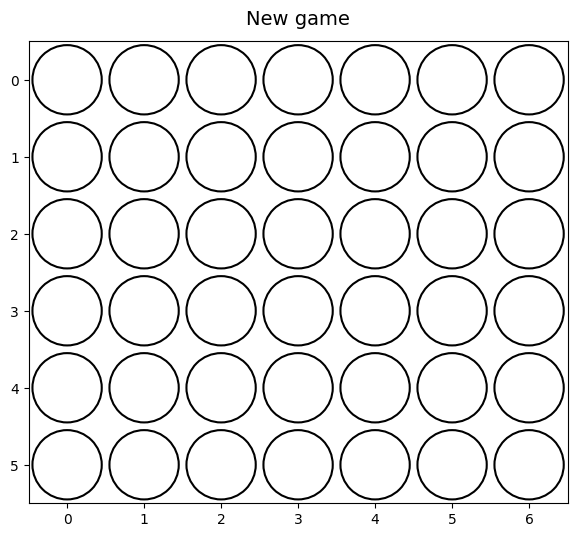

Root child summary (column, value, visits, pruned):
  0 |     10 | visits= 1578 | pruned=YES
  1 |     14 | visits= 1581 | pruned=YES
  2 |     21 | visits= 2066 | pruned=YES
  3 |     22 | visits= 2249 | pruned=YES  <== chosen
  4 |     21 | visits= 1596 | pruned=YES
  5 |     18 | visits= 1545 | pruned=YES
  6 |     21 | visits=  556 | pruned=YES
Valid columns: [0, 1, 2, 3, 4, 5, 6]
Your move (column index): 1


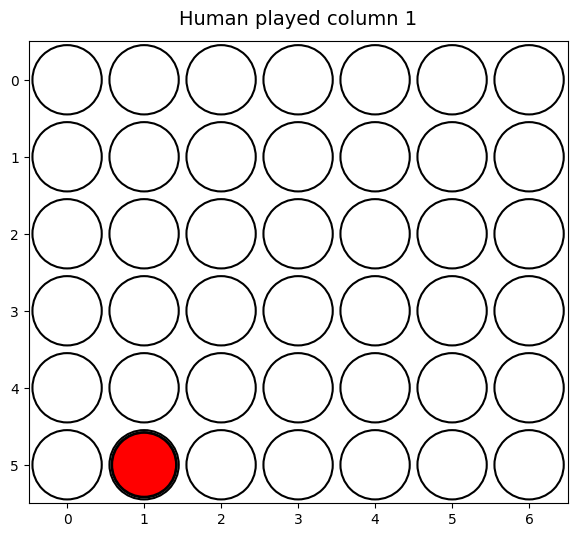

Root child summary (column, value, visits, pruned):
  0 |     -5 | visits= 1339 | pruned=YES
  1 |    -18 | visits= 2244 | pruned=YES
  2 |    -16 | visits=  915 | pruned=YES
  3 |    -18 | visits= 1350 | pruned=YES
  4 |    -19 | visits= 2662 | pruned=YES  <== chosen
  5 |    -19 | visits=  583 | pruned=YES
  6 |    -19 | visits=  488 | pruned=YES


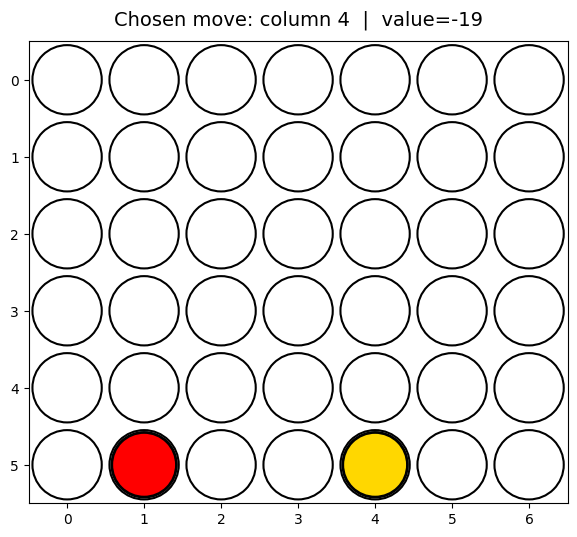

Root child summary (column, value, visits, pruned):
  0 |     -6 | visits= 2642 | pruned=YES
  1 |     14 | visits= 2251 | pruned=YES
  2 |     13 | visits=  992 | pruned=YES
  3 |     31 | visits= 1679 | pruned=YES  <== chosen
  4 |     30 | visits=  373 | pruned=YES
  5 |     25 | visits=  338 | pruned=YES
  6 |     20 | visits=  374 | pruned=YES
Valid columns: [0, 1, 2, 3, 4, 5, 6]


KeyboardInterrupt: Interrupted by user

In [43]:
# AI vs AI:
#play_game(depth_max=5, start_player=PLAYER_MAX, human_plays=None)
# Human vs AI (you are MAX):
play_game(depth_max=5, start_player=PLAYER_MAX, human_plays=PLAYER_MAX)


## 9) Save Artifacts & Download

In [44]:
import os, json
os.makedirs("artifacts", exist_ok=True)
snapshot = {"rows": ROWS, "cols": COLS, "final_board": None}
try:
    snapshot["final_board"] = s.board.tolist()
except Exception:
    pass
with open("artifacts/connect4_snapshot.json", "w") as f:
    json.dump(snapshot, f, indent=2)
print("Saved artifacts:", os.listdir("artifacts"))


Saved artifacts: ['connect4_snapshot.json']


In [45]:
# Colab download helper
import shutil
from pathlib import Path
try:
    from google.colab import files  # type: ignore
    if Path('artifacts').exists():
        shutil.make_archive('artifacts', 'zip', 'artifacts')
        files.download('artifacts.zip')
    else:
        print('No artifacts folder found.')
except Exception as e:
    print('Colab download helper not available in this environment:', e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11) Extensions & Exercises

- Add quiescence or late-move reductions.
- Use a **threat-space** evaluator, or implement **MCTS** for comparison.
- Add opening book or solve smaller boards exactly.